In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
# device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
# dataset

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [4]:
# build the mlp

class CNN1(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )


    def forward(self, x):
        x = self.features(x)
        x = self.clf(x)
        return x

model1 = CNN1().to(device)

In [5]:
# build the mlp

class CNN2(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )


    def forward(self, x):
        x = self.features(x)
        x = self.clf(x)
        return x

model2 = CNN2().to(device)

In [6]:
# loss, optimizer

criterion = nn.CrossEntropyLoss()

optimizer1 = optim.Adam(
    params=model1.parameters(),
    lr=0.01
)

optimizer2 = optim.Adam(
    params=model2.parameters(),
    lr=0.01
)

In [7]:
# metrics storage

training_acc_1 = []
training_loss_1 = []
validation_acc_1 = []
validation_loss_1 = []

training_acc_2 = []
training_loss_2 = []
validation_acc_2 = []
validation_loss_2 = []

In [8]:
# training function

def train_one_epoch1(model, loader):
    model.train()

    running_loss = 0
    correct  = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer1.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer1.step()

        running_loss += loss.item()
        predictions = outputs.argmax(1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy


def train_one_epoch2(model, loader):
    model.train()

    running_loss = 0
    correct  = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer2.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer2.step()

        running_loss += loss.item()
        predictions = outputs.argmax(1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [9]:
# validation function

def validation(model, loader):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            running_loss += loss.item()
            predictions = outputs.argmax(1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [10]:
# training loop

epochs = 15

print("------------------Model1-----------------")
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch1(
        model1, train_loader
    )
    val_loss, val_acc = validation(
        model1, test_loader
    )

    training_loss_1.append(train_loss)
    training_acc_1.append(train_acc)
    validation_loss_1.append(val_loss)
    validation_acc_1.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )


print("------------------Model2-----------------")
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch2(
        model2, train_loader
    )
    val_loss, val_acc = validation(
        model2, test_loader
    )

    training_loss_2.append(train_loss)
    training_acc_2.append(train_acc)
    validation_loss_2.append(val_loss)
    validation_acc_2.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

------------------Model1-----------------
Epoch  1 | Train Loss 0.4729 | Train Acc 0.8240 | Val Loss 0.3981 | Val Acc 0.8602
Epoch  2 | Train Loss 0.3266 | Train Acc 0.8787 | Val Loss 0.3685 | Val Acc 0.8705
Epoch  3 | Train Loss 0.3022 | Train Acc 0.8885 | Val Loss 0.3177 | Val Acc 0.8863
Epoch  4 | Train Loss 0.2850 | Train Acc 0.8956 | Val Loss 0.3170 | Val Acc 0.8871
Epoch  5 | Train Loss 0.2779 | Train Acc 0.8970 | Val Loss 0.3172 | Val Acc 0.8907
Epoch  6 | Train Loss 0.2688 | Train Acc 0.8994 | Val Loss 0.3175 | Val Acc 0.8842
Epoch  7 | Train Loss 0.2623 | Train Acc 0.9031 | Val Loss 0.3369 | Val Acc 0.8837
Epoch  8 | Train Loss 0.2556 | Train Acc 0.9049 | Val Loss 0.3194 | Val Acc 0.8906
Epoch  9 | Train Loss 0.2500 | Train Acc 0.9078 | Val Loss 0.3166 | Val Acc 0.8868
Epoch 10 | Train Loss 0.2491 | Train Acc 0.9077 | Val Loss 0.3305 | Val Acc 0.8910
Epoch 11 | Train Loss 0.2440 | Train Acc 0.9100 | Val Loss 0.3523 | Val Acc 0.8834
Epoch 12 | Train Loss 0.2415 | Train Acc 0.90

Adding one extra layer for feature processing resulted in a slightly worse accuracy and resulted in higher loss.

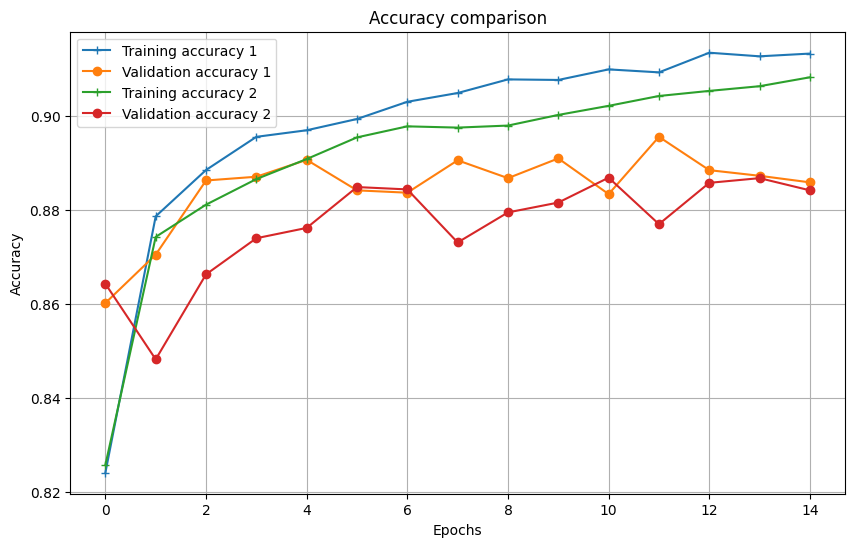

In [15]:
# plotting

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(training_acc_1, label="Training accuracy 1", marker='+')
plt.plot(validation_acc_1, label='Validation accuracy 1', marker='o')
plt.plot(training_acc_2, label="Training accuracy 2", marker='+')
plt.plot(validation_acc_2, label='Validation accuracy 2', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy comparison")
plt.grid(True)
plt.legend()
plt.show()

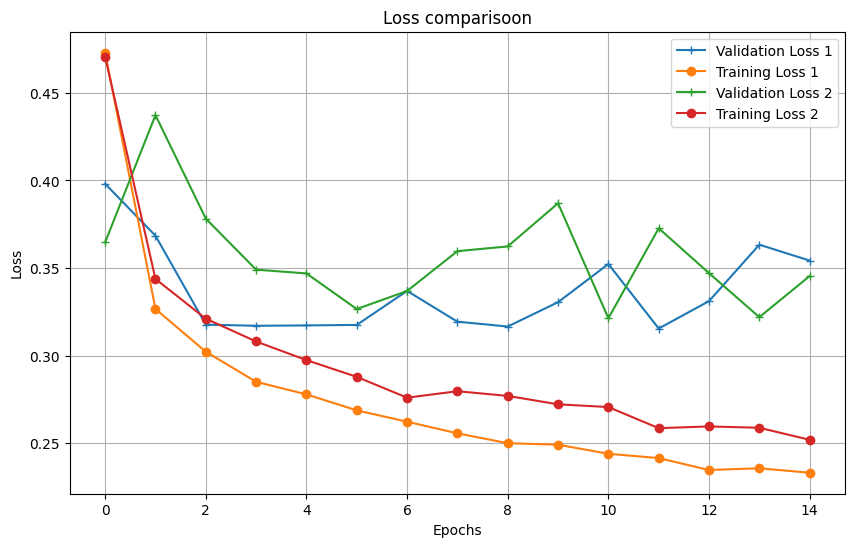

In [16]:
plt.figure(figsize=(10,6))
plt.plot(validation_loss_1, label="Validation Loss 1", marker='+')
plt.plot(training_loss_1, label="Training Loss 1", marker='o')
plt.plot(validation_loss_2, label="Validation Loss 2", marker='+')
plt.plot(training_loss_2, label="Training Loss 2", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss comparisoon")
plt.legend()
plt.grid(True)
plt.show()